In [5]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from torch.utils.data import Dataset, DataLoader

In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Device : cuda
GPU : NVIDIA GeForce RTX 3060 Ti


In [ ]:
df = pd.read_csv("../output/dataset_preprocessing.csv")

print(df.shape)

df.head()

In [4]:
MAX_LENGTH = 128

test_dataset = IndoBERTDataset(

    test_df["hasil_preprocessing"],

    test_df["label"],

    tokenizer,

    MAX_LENGTH

)

NameError: name 'test_df' is not defined

In [7]:
from transformers import AutoTokenizer

MODEL_PATH = "../model/indobert_best"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

In [9]:
import pandas as pd

df = pd.read_csv("../output/dataset_preprocessing.csv")

print(df.shape)
print(df.columns)

(20807, 10)
Index(['label', 'author', 'comment', 'id', 'channel', 'title', 'cleaning',
       'casefolding', 'normalisasi', 'hasil_preprocessing'],
      dtype='str')


In [10]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train :", len(train_df))
print("Validation :", len(valid_df))
print("Test :", len(test_df))

Train : 16645
Validation : 2081
Test : 2081


In [11]:
MODEL_PATH = "../model/indobert_best"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

model.to(device)

model.eval()

print("Model berhasil dimuat.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model berhasil dimuat.


In [12]:
class IndoBERTDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_length):

        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        encoding = self.tokenizer(

            str(self.texts[idx]),

            truncation=True,

            padding="max_length",

            max_length=self.max_length,

            return_tensors="pt"

        )

        return {

            "input_ids": encoding["input_ids"].flatten(),

            "attention_mask": encoding["attention_mask"].flatten(),

            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )

        }

In [13]:
MAX_LENGTH = 128

test_dataset = IndoBERTDataset(

    test_df["hasil_preprocessing"],

    test_df["label"],

    tokenizer,

    MAX_LENGTH

)

print(len(test_dataset))

2081


In [14]:
BATCH_SIZE = 16

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)

print(len(test_loader))

131


In [15]:
predictions = []

true_labels = []

model.eval()

with torch.no_grad():

    for batch in tqdm(test_loader, desc="Testing"):

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask

        )

        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())

        true_labels.extend(labels.cpu().numpy())

Testing:   0%|          | 0/131 [00:00<?, ?it/s]

In [16]:
accuracy = accuracy_score(
    true_labels,
    predictions
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9779


In [17]:
precision = precision_score(
    true_labels,
    predictions
)

recall = recall_score(
    true_labels,
    predictions
)

f1 = f1_score(
    true_labels,
    predictions
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.9728
Recall    : 0.9839
F1 Score  : 0.9783


In [18]:
report = classification_report(

    true_labels,

    predictions,

    target_names=[

        "Bukan Judi Online",

        "Judi Online"

    ]

)

print(report)

                   precision    recall  f1-score   support

Bukan Judi Online       0.98      0.97      0.98      1028
      Judi Online       0.97      0.98      0.98      1053

         accuracy                           0.98      2081
        macro avg       0.98      0.98      0.98      2081
     weighted avg       0.98      0.98      0.98      2081



In [20]:
with open(
    "../output/classification_report.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(report)

print("Classification report berhasil disimpan.")

Classification report berhasil disimpan.


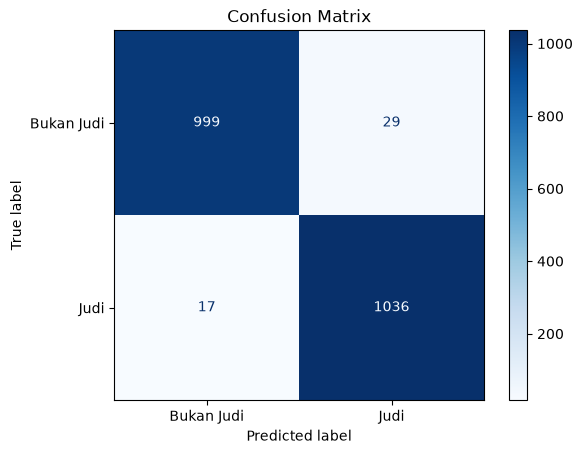

In [21]:
cm = confusion_matrix(
    true_labels,
    predictions
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[

        "Bukan Judi",

        "Judi"

    ]

)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")

plt.savefig(
    "../output/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
metrics = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1

    ]

})

metrics.to_csv(

    "../output/evaluation_metrics.csv",

    index=False

)

metrics

,Metric,Value
0,Accuracy,0.977895
1,Precision,0.972770
2,Recall,0.983856
3,F1 Score,0.978281


In [23]:
result = pd.DataFrame({

    "Text": test_df["hasil_preprocessing"].values,

    "Actual": true_labels,

    "Prediction": predictions

})

result.to_csv(

    "../output/prediction_result.csv",

    index=False,

    encoding="utf-8-sig"

)

result.head(20)

,Text,Actual,Prediction
0,tidak bisa di pungkiri mandalika77 emg terbaik...,1,1
1,literally bikin sultan di bowo88 modal receh b...,1,1
2,bagaimana kabar shi lhu cho cha,0,0
3,yuka sopan banget respect,0,0
4,ngeliatnya kaya ini tu mobil keluarga premium ...,0,0
5,itu bukan kebijakan strategis tapi biasa sonas...,0,0
6,pengalaman bermain di nagaplay138 dengan promo...,1,1
7,rekomendasi terbaik buat cari hiburan yang gac...,1,1
8,mereka yang pacaran nikah malah aku yang kesen...,0,0
9,main di megabet99 dapet scatter langsung wd 1 ...,1,1
